**Table of contents**<a id='toc0_'></a>    
- [Question Markus: how does it look like if 50% are localized 1-2 times, 50% are localized 5 times?](#toc1_)    
  - [Bleaching probability](#toc1_1_)    
  - [OFF time](#toc1_2_)    
  - [ON to OFF probability](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Question Markus: how does it look like if 50% are localized 1-2 times, 50% are localized 5 times?](#toc0_)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.figure as fi

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

reading_from = r"D:\python_output\Chapter_I\0_3_single_f_PFA"

## <a id='toc1_1_'></a>[Bleaching probability](#toc0_)

(300001, 500)
Mean ON events: 23.86, Mean locs: 752.468
(300001, 500)
Mean ON events: 1.194, Mean locs: 6.822


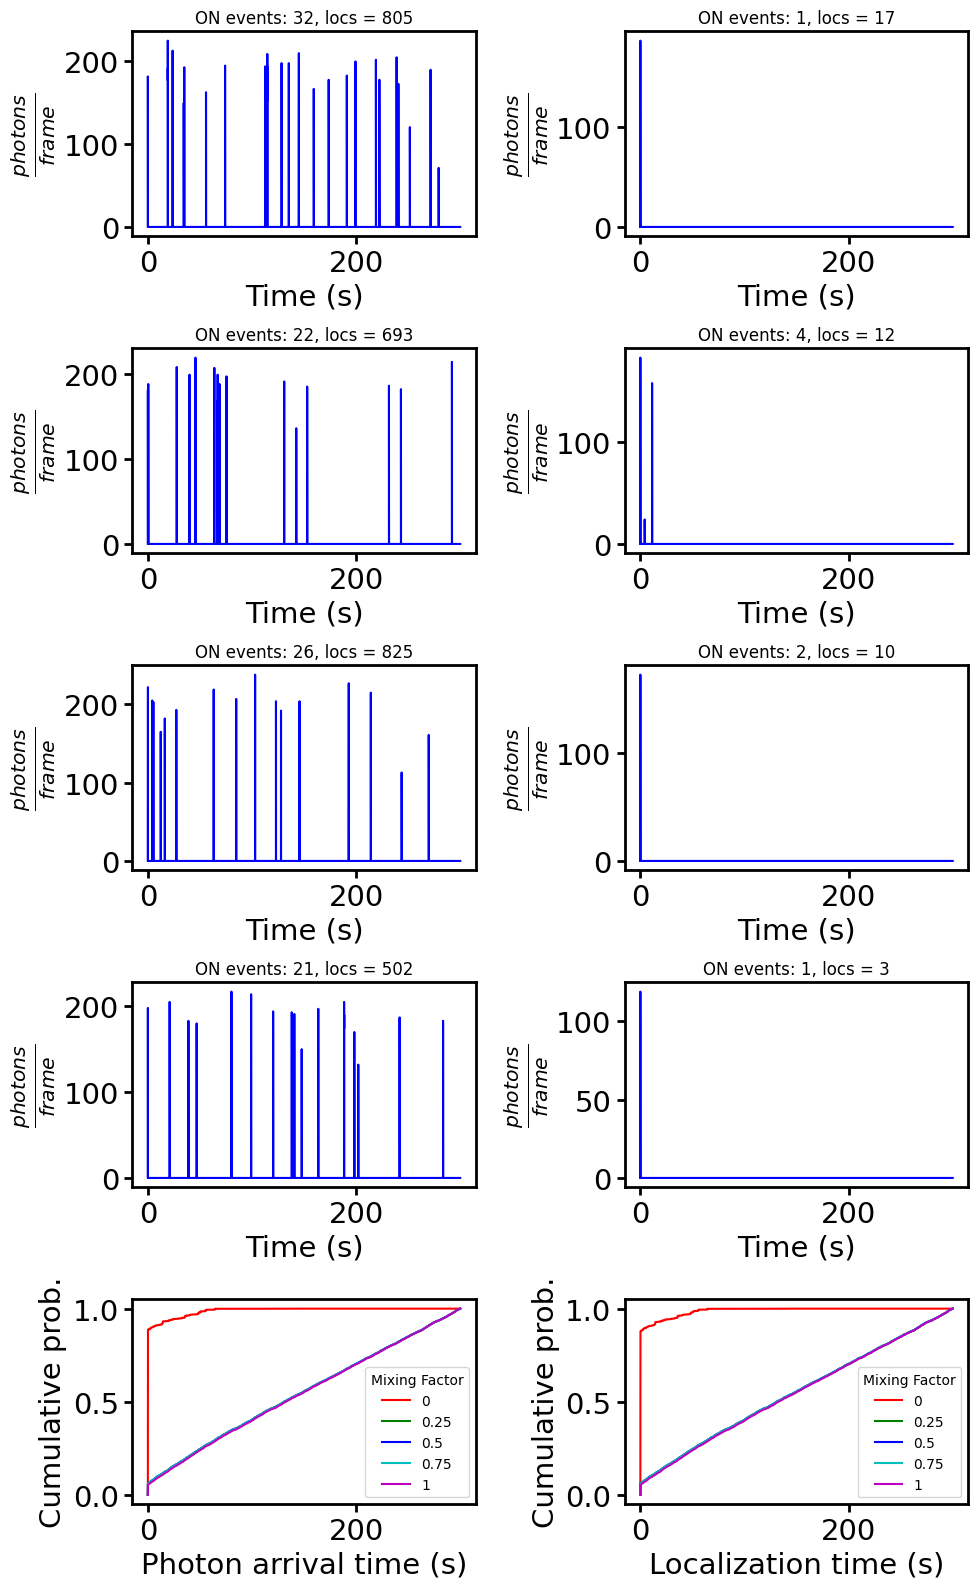

In [49]:
gs = plt.GridSpec(5, 2)
fig = plt.figure(figsize=(10, 16))

# standard bleaching probability

df_1 = pd.read_parquet(
    r"D:\python_output\Chapter_I\0_3_single_f_PFA\bl_rate\1e1\single_runs_bl_rate_1e1_batch_0.parquet"
)
print(df_1.shape)  # making sure the dataframes are of the same size
emis = em.Emissions()
all_on_events = []
all_loc_counts = []
for i, col in enumerate(df_1.columns):
    emis.event_time_series = df_1[col]
    loc_count = (emis.event_time_series > 0).sum()
    blinks = bl.Blinking(emis)
    all_on_events.append(blinks.on_periods.size)
    all_loc_counts.append(loc_count)
    if i < 4:
        ax = fig.add_subplot(gs[i, 0])
        emis.plot_time_series(axes=ax)
        ax.set_title(f"ON events: {blinks.on_periods.size}, locs = {loc_count}")
print(f"Mean ON events: {np.mean(all_on_events)}, Mean locs: {np.mean(all_loc_counts)}")

# high bleaching probability

df_2 = pd.read_parquet(
    r"D:\python_output\Chapter_I\0_3_single_f_PFA\bl_rate\1e4\single_runs_bl_rate_1e4_batch_0.parquet"
)
print(df_2.shape)
emis = em.Emissions()
all_on_events = []
all_loc_counts = []
for i, col in enumerate(df_2.columns):
    emis.event_time_series = df_2[col]
    loc_count = (emis.event_time_series > 0).sum()
    blinks = bl.Blinking(emis)
    all_on_events.append(blinks.on_periods.size)
    all_loc_counts.append(loc_count)
    if i < 4:
        ax = fig.add_subplot(gs[i, 1])
        emis.plot_time_series(axes=ax)
        ax.set_title(f"ON events: {blinks.on_periods.size}, locs = {loc_count}")
print(f"Mean ON events: {np.mean(all_on_events)}, Mean locs: {np.mean(all_loc_counts)}")

mixing_factors = [0, 0.25, 0.5, 0.75, 1]
colors = ["r", "g", "b", "c", "m"]
ax1 = fig.add_subplot(gs[4, 0])
ax2 = fig.add_subplot(gs[4, 1])
for i, factor in enumerate(mixing_factors):
    fingerprint = pd.Series(
        np.zeros(300001),
        np.round(np.linspace(0, 300, 300001), decimals=12),
        dtype=np.int32,
    )
    localizations = pd.Series(
        np.zeros(300001),
        np.round(np.linspace(0, 300, 300001), decimals=12),
        dtype=np.int32,
    )
    fingerprint += df_1.iloc[:, : int(factor * len(df_1))].sum(axis=1)
    fingerprint += df_2.iloc[:, : int((1 - factor) * len(df_2))].sum(axis=1)
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    localizations += (df_1.iloc[:, : int(factor * len(df_1))] > 0).sum(axis=1)
    localizations += (df_2.iloc[:, : int((1 - factor) * len(df_2))] > 0).sum(axis=1)
    localizations = localizations.cumsum() / localizations.sum()
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        axes=ax1,
        color=colors[i],
        label=f"{factor}",
        legend=True,
        legendargs={"title": "Mixing Factor"},
        xlabel="Photon arrival time (s)",
        ylabel="Cumulative prob.",
    )
    fi.universal_figure(
        data=[localizations.index, localizations],
        axes=ax2,
        color=colors[i],
        label=f"{factor}",
        legend=True,
        legendargs={"title": "Mixing Factor"},
        xlabel="Localization time (s)",
        ylabel="Cumulative prob.",
    )
fig.tight_layout()
fig.savefig(r"c:\Users\vie43sq\Downloads\ble_rate_mixing.png", dpi=300)

## <a id='toc1_2_'></a>[OFF time](#toc0_)

(300001, 500)
Mean ON events: 24.43, Mean locs: 763.712
(300001, 300)
Mean ON events: 202.39333333333335, Mean locs: 6665.406666666667


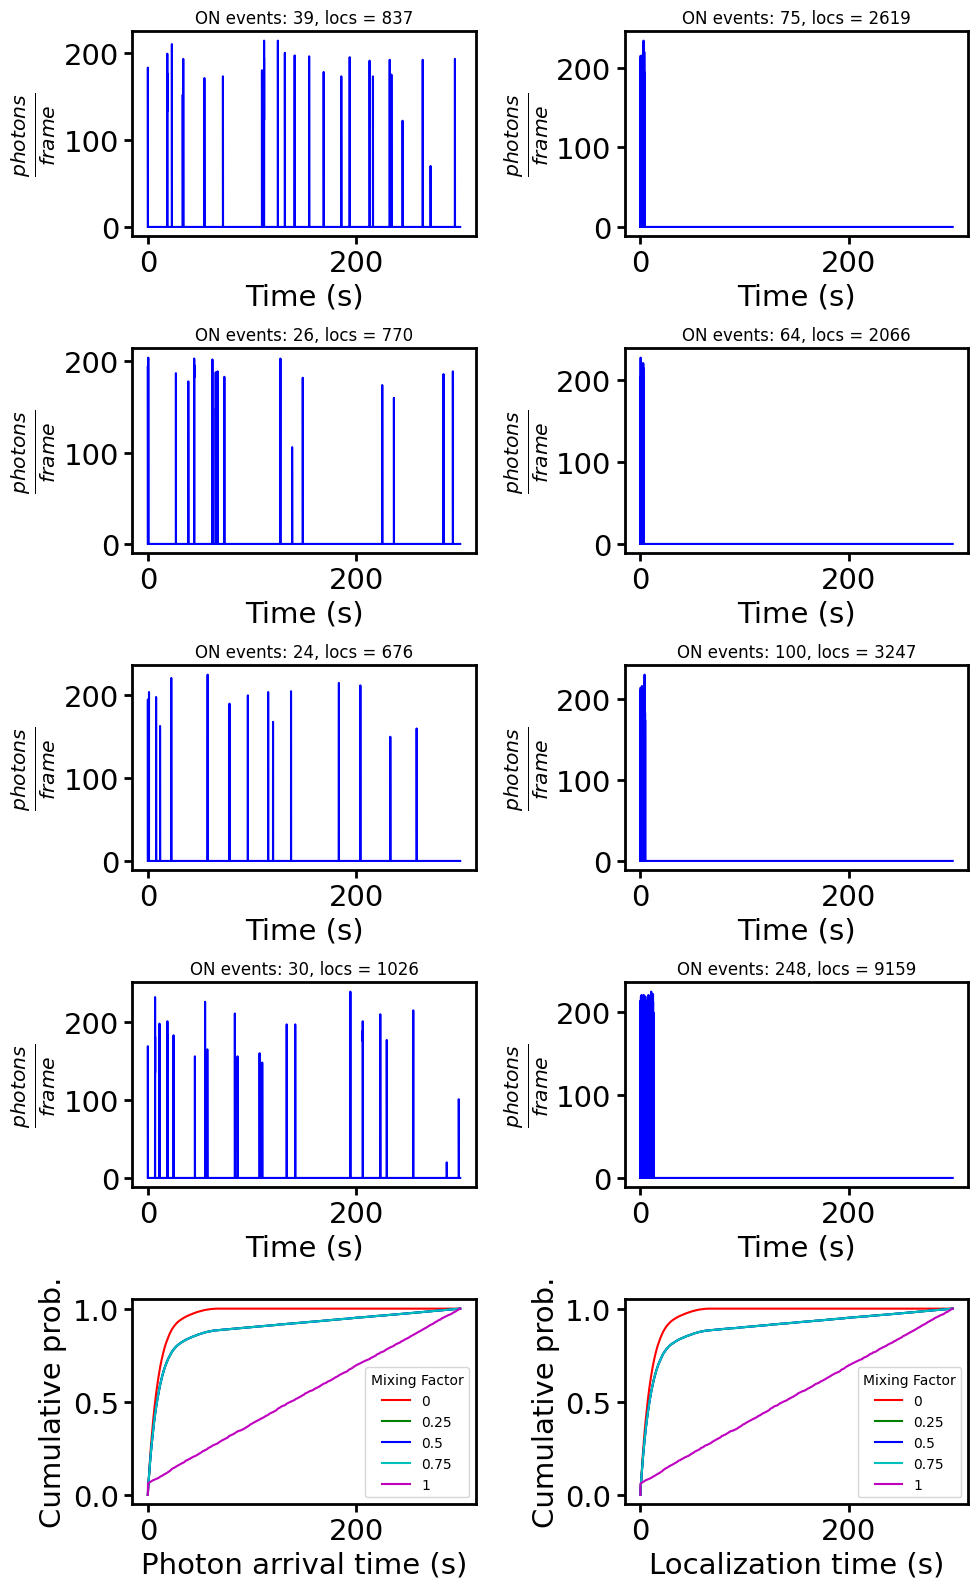

In [50]:
gs = plt.GridSpec(5, 2)
fig = plt.figure(figsize=(10, 16))

# standard off time

df_1 = pd.read_parquet(
    r"D:\python_output\Chapter_I\0_3_single_f_PFA\off_time\5e-2\single_runs_off_on_5e-2_batch_0.parquet"
)
print(df_1.shape)  # making sure the dataframes are of the same size
emis = em.Emissions()
all_on_events = []
all_loc_counts = []
for i, col in enumerate(df_1.columns):
    emis.event_time_series = df_1[col]
    loc_count = (emis.event_time_series > 0).sum()
    blinks = bl.Blinking(emis)
    all_on_events.append(blinks.on_periods.size)
    all_loc_counts.append(loc_count)
    if i < 4:
        ax = fig.add_subplot(gs[i, 0])
        emis.plot_time_series(axes=ax)
        ax.set_title(f"ON events: {blinks.on_periods.size}, locs = {loc_count}")
print(f"Mean ON events: {np.mean(all_on_events)}, Mean locs: {np.mean(all_loc_counts)}")

# low off time

df_2 = pd.read_parquet(
    r"D:\python_output\Chapter_I\0_3_single_f_PFA\off_time\5e1\single_runs_off_on_5e1_batch_0.parquet"
)
print(df_2.shape)
emis = em.Emissions()
all_on_events = []
all_loc_counts = []
for i, col in enumerate(df_2.columns):
    emis.event_time_series = df_2[col]
    loc_count = (emis.event_time_series > 0).sum()
    blinks = bl.Blinking(emis)
    all_on_events.append(blinks.on_periods.size)
    all_loc_counts.append(loc_count)
    if i < 4:
        ax = fig.add_subplot(gs[i, 1])
        emis.plot_time_series(axes=ax)
        ax.set_title(f"ON events: {blinks.on_periods.size}, locs = {loc_count}")
print(f"Mean ON events: {np.mean(all_on_events)}, Mean locs: {np.mean(all_loc_counts)}")

mixing_factors = [0, 0.25, 0.5, 0.75, 1]
colors = ["r", "g", "b", "c", "m"]
ax1 = fig.add_subplot(gs[4, 0])
ax2 = fig.add_subplot(gs[4, 1])
for i, factor in enumerate(mixing_factors):
    fingerprint = pd.Series(
        np.zeros(300001),
        np.round(np.linspace(0, 300, 300001), decimals=12),
        dtype=np.int32,
    )
    localizations = pd.Series(
        np.zeros(300001),
        np.round(np.linspace(0, 300, 300001), decimals=12),
        dtype=np.int32,
    )
    fingerprint += df_1.iloc[:, : int(factor * len(df_1))].sum(axis=1)
    fingerprint += df_2.iloc[:, : int((1 - factor) * len(df_2))].sum(axis=1)
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    localizations += (df_1.iloc[:, : int(factor * len(df_1))] > 0).sum(axis=1)
    localizations += (df_2.iloc[:, : int((1 - factor) * len(df_2))] > 0).sum(axis=1)
    localizations = localizations.cumsum() / localizations.sum()
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        axes=ax1,
        color=colors[i],
        label=f"{factor}",
        legend=True,
        legendargs={"title": "Mixing Factor"},
        xlabel="Photon arrival time (s)",
        ylabel="Cumulative prob.",
    )
    fi.universal_figure(
        data=[localizations.index, localizations],
        axes=ax2,
        color=colors[i],
        label=f"{factor}",
        legend=True,
        legendargs={"title": "Mixing Factor"},
        xlabel="Localization time (s)",
        ylabel="Cumulative prob.",
    )
fig.tight_layout()
fig.savefig(r"c:\Users\vie43sq\Downloads\off_time_mixing.png", dpi=300)

## <a id='toc1_3_'></a>[ON to OFF probability](#toc0_)

(300001, 500)
Mean ON events: 24.128, Mean locs: 764.046
(300001, 100)
Mean ON events: 60.01, Mean locs: 6641.61


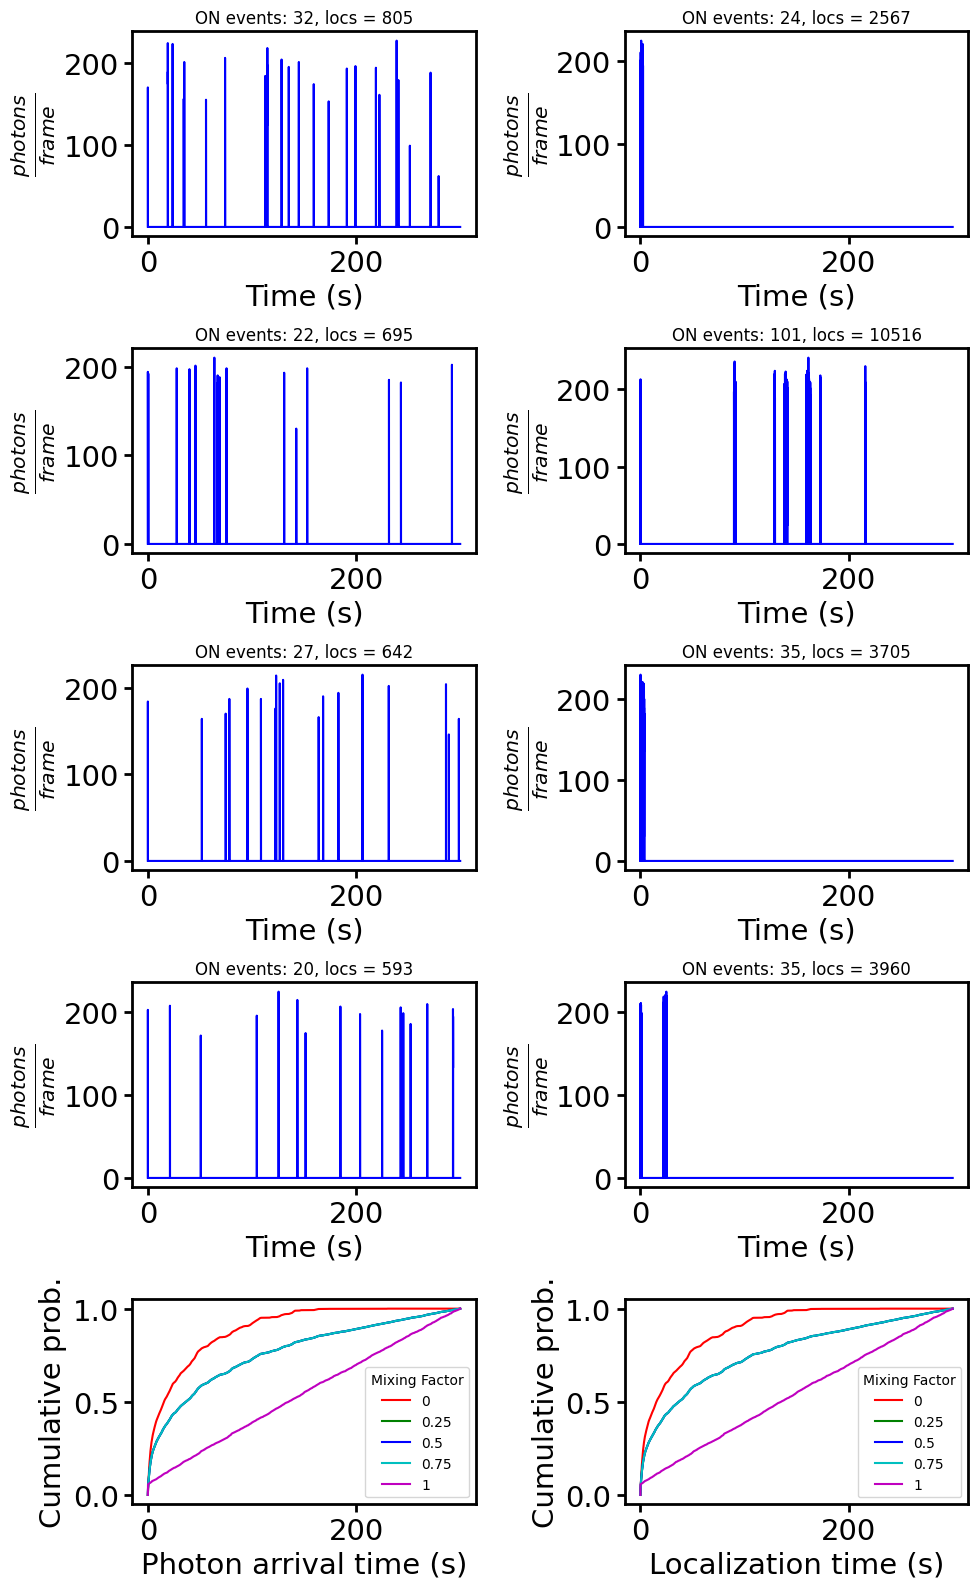

: 

In [ ]:
gs = plt.GridSpec(5, 2)
fig = plt.figure(figsize=(10, 16))

# standard on off probability

df_1 = pd.read_parquet(
    r"D:\python_output\Chapter_I\0_3_single_f_PFA\off_prob\1\single_runs_red1_batch_0.parquet"
)
print(df_1.shape)  # making sure the dataframes are of the same size
emis = em.Emissions()
all_on_events = []
all_loc_counts = []
for i, col in enumerate(df_1.columns):
    emis.event_time_series = df_1[col]
    loc_count = (emis.event_time_series > 0).sum()
    blinks = bl.Blinking(emis)
    all_on_events.append(blinks.on_periods.size)
    all_loc_counts.append(loc_count)
    if i < 4:
        ax = fig.add_subplot(gs[i, 0])
        emis.plot_time_series(axes=ax)
        ax.set_title(f"ON events: {blinks.on_periods.size}, locs = {loc_count}")
print(f"Mean ON events: {np.mean(all_on_events)}, Mean locs: {np.mean(all_loc_counts)}")

# low on off probability

df_2 = pd.read_parquet(
    r"D:\python_output\Chapter_I\0_3_single_f_PFA\off_prob\001\single_runs_red001_batch_0.parquet"
)
print(df_2.shape)
emis = em.Emissions()
all_on_events = []
all_loc_counts = []
for i, col in enumerate(df_2.columns):
    emis.event_time_series = df_2[col]
    loc_count = (emis.event_time_series > 0).sum()
    blinks = bl.Blinking(emis)
    all_on_events.append(blinks.on_periods.size)
    all_loc_counts.append(loc_count)
    if i < 4:
        ax = fig.add_subplot(gs[i, 1])
        emis.plot_time_series(axes=ax)
        ax.set_title(f"ON events: {blinks.on_periods.size}, locs = {loc_count}")
print(f"Mean ON events: {np.mean(all_on_events)}, Mean locs: {np.mean(all_loc_counts)}")

mixing_factors = [0, 0.25, 0.5, 0.75, 1]
colors = ["r", "g", "b", "c", "m"]
ax1 = fig.add_subplot(gs[4, 0])
ax2 = fig.add_subplot(gs[4, 1])
for i, factor in enumerate(mixing_factors):
    fingerprint = pd.Series(
        np.zeros(300001),
        np.round(np.linspace(0, 300, 300001), decimals=12),
        dtype=np.int32,
    )
    localizations = pd.Series(
        np.zeros(300001),
        np.round(np.linspace(0, 300, 300001), decimals=12),
        dtype=np.int32,
    )
    fingerprint += df_1.iloc[:, : int(factor * len(df_1))].sum(axis=1)
    fingerprint += df_2.iloc[:, : int((1 - factor) * len(df_2))].sum(axis=1)
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    localizations += (df_1.iloc[:, : int(factor * len(df_1))] > 0).sum(axis=1)
    localizations += (df_2.iloc[:, : int((1 - factor) * len(df_2))] > 0).sum(axis=1)
    localizations = localizations.cumsum() / localizations.sum()
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        axes=ax1,
        color=colors[i],
        label=f"{factor}",
        legend=True,
        legendargs={"title": "Mixing Factor"},
        xlabel="Photon arrival time (s)",
        ylabel="Cumulative prob.",
    )
    fi.universal_figure(
        data=[localizations.index, localizations],
        axes=ax2,
        color=colors[i],
        label=f"{factor}",
        legend=True,
        legendargs={"title": "Mixing Factor"},
        xlabel="Localization time (s)",
        ylabel="Cumulative prob.",
    )
fig.tight_layout()
fig.savefig(r"c:\Users\vie43sq\Downloads\on_off_prob_mixing.png", dpi=300)